
**Two-Sample, Equal Variance t-Test: Supplier Quality Control Simulation**

This project simulates a quality control scenario where we evaluate whether we can switch to a cheaper component supplier without compromising product quality.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

_Data Generation_

Simulating tensile strength testing (in Newtons) for 30 connectors from each supplier.

In [7]:
np.random.seed(42)
n1, n2 = 30, 30

# Modelling a situation, where the true strength is almost equal and deviations are equal
supplier_1 = np.random.normal(loc=48.5, scale=3.0, size=n1)
supplier_2 = np.random.normal(loc=47.8, scale=3.0, size=n2)

_Statistical Analysis (Formulas & Verification)_

Calculating the pooled standard deviation ($s_p$), degrees of freedom ($DF$), $t$-statistic, and $p$-value.

In [8]:
x1_bar = np.mean(supplier_1)
x2_bar = np.mean(supplier_2)
s1 = np.std(supplier_1, ddof=1)
s2 = np.std(supplier_2, ddof=1)

df = n1 + n2 - 2
s_p = np.sqrt(((n1 - 1) * (s1**2) + (n2 - 1) * (s2**2)) / df)

t_stat, p_val = stats.ttest_ind(supplier_1, supplier_2, equal_var=True)

print(f"Supplier 1 (Mean): {x1_bar:.2f} N | St. deviation (s1): {s1:.2f} N")
print(f"Supplier 2 (Mean): {x2_bar:.2f} N | St. deciation (s2): {s2:.2f} N")
print(f"\nt-test results:")
print(f"pooled standard deviation (s_p): {s_p:.2f} N")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Supplier 1 (Mean): 47.94 N | St. deviation (s1): 2.70 N
Supplier 2 (Mean): 47.44 N | St. deciation (s2): 2.79 N

t-test results:
pooled standard deviation (s_p): 2.75 N
t-statistic: 0.7036
p-value: 0.4845


_Data Visualization_

Creating a combined Boxplot and Stripplot.

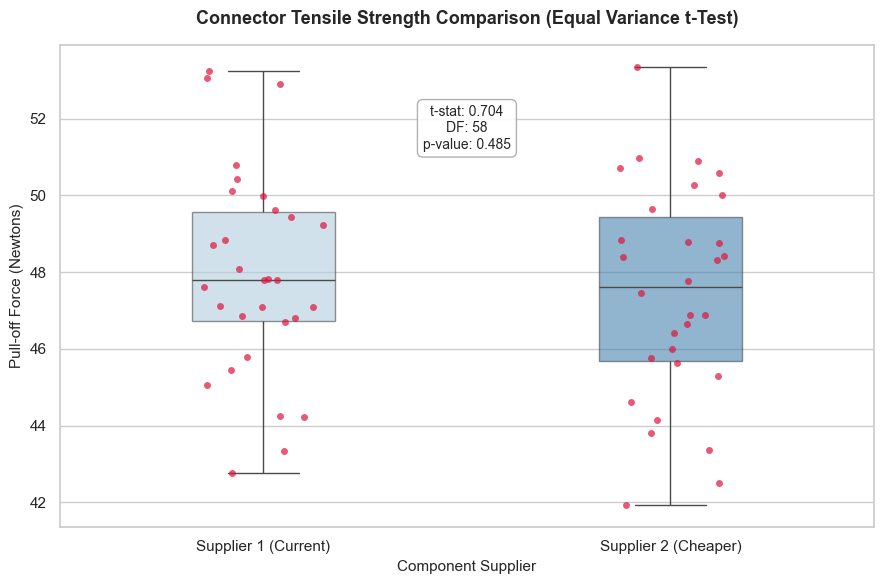

In [10]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

plot_data = pd.DataFrame({
    'Force': np.concatenate([supplier_1, supplier_2]),
    'Supplier': ['Supplier 1 (Current)'] * n1 + ['Supplier 2 (Cheaper)'] * n2
})

sns.boxplot(x='Supplier', y='Force', data=plot_data, palette='Blues', width=0.35, boxprops=dict(alpha=0.6), hue='Supplier')
sns.stripplot(x='Supplier', y='Force', data=plot_data, color='crimson', size=5, jitter=0.15, alpha=0.7)

plt.title('Connector Tensile Strength Comparison (Equal Variance t-Test)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Component Supplier', fontsize=11)
plt.ylabel('Pull-off Force (Newtons)', fontsize=11)

result_text = f"t-stat: {t_stat:.3f}\nDF: {df}\np-value: {p_val:.3f}"
plt.text(0.5, plot_data['Force'].max() - 1, result_text, ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='darkgray', alpha=0.9), fontsize=10)

plt.tight_layout()
# plt.savefig('connector_strength_t_test.png', dpi=300)
plt.show()